In [ ]:
'''

Motivation 動機與應用背景
不確定性傳播（uncertainty propagation）：給定隨機向量 X，如何推導 Y=f(X) 的分布或某些期望值？

建模：
邊際分布通常較容易獲得（資料或專家知識）

各變數間的相依性卻常不清楚 → copula 可用來建模 joint structure



定義：Copula 是在單位立方體 [0,1] n上，邊際分布皆為 uniform 的 joint CDF

用於模擬 若x, y變數(單調函數)滿足copula ， 之後再喬出想要的邊際函數



'''

In [ ]:
# generate multivariate normal

In [1]:
import numpy as np

import random

In [2]:

c = np.array([
    [1,0.5,0.5],
    [0.5,1,0.5],
    [0.5,0.5,1],
])

In [4]:
# cholesky decompsition


A = np.linalg.cholesky(c)

In [5]:
A

array([[1.        , 0.        , 0.        ],
       [0.5       , 0.8660254 , 0.        ],
       [0.5       , 0.28867513, 0.81649658]])

In [6]:
z = [[],[],[]]
for i in range(3):
    for j in range(10000):
        u = random.uniform(0, 1)
    
        r = -2 * np.log(u)
    
        theta = random.uniform(0, 2 * np.pi)
    
        z[i].append(r**0.5 * np.cos(theta))
        

In [8]:
z = np.array(z)

In [9]:
X = np.dot(A, z)

In [10]:
X1 = X[0]
X2 = X[1]
X3 = X[2]

(array([  13.,   79.,  488., 1478., 2761., 2844., 1683.,  536.,  103.,
          15.]),
 array([-3.87130227, -3.10712587, -2.34294946, -1.57877306, -0.81459666,
        -0.05042025,  0.71375615,  1.47793256,  2.24210896,  3.00628536,
         3.77046177]),
 <BarContainer object of 10 artists>)

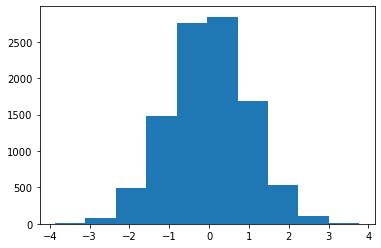

In [11]:
import matplotlib.pyplot as plt

plt.hist(X1)

In [12]:
np.corrcoef(X1,X2)

array([[1.        , 0.48328046],
       [0.48328046, 1.        ]])

In [15]:
#Xi  mean 0, var 1 ,cov 0.5

# gaussian copula

from scipy.stats import norm

cdf1 = norm.cdf(X1)
cdf2 = norm.cdf(X2)
cdf3 = norm.cdf(X3)


(array([ 999.,  987., 1041.,  976.,  999., 1052.,  993.,  977., 1014.,
         962.]),
 array([5.41277251e-05, 1.00040568e-01, 2.00027008e-01, 3.00013448e-01,
        3.99999887e-01, 4.99986327e-01, 5.99972767e-01, 6.99959207e-01,
        7.99945647e-01, 8.99932087e-01, 9.99918527e-01]),
 <BarContainer object of 10 artists>)

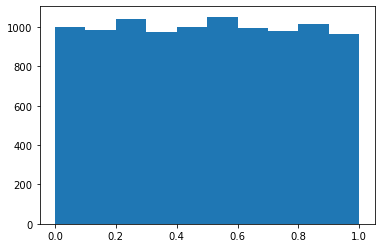

In [16]:
plt.hist(cdf1) # 得到三個，邊際分布U(0,1)

In [17]:
c = np.vstack([cdf1, cdf2, cdf3])

In [19]:
# 經反函數法，可得出exp(1)

Y = np.log(c) * -1


(array([6.258e+03, 2.344e+03, 8.800e+02, 3.250e+02, 1.300e+02, 3.400e+01,
        1.500e+01, 1.100e+01, 1.000e+00, 2.000e+00]),
 array([8.14762020e-05, 9.82489731e-01, 1.96489799e+00, 2.94730624e+00,
        3.92971450e+00, 4.91212275e+00, 5.89453101e+00, 6.87693926e+00,
        7.85934751e+00, 8.84175577e+00, 9.82416402e+00]),
 <BarContainer object of 10 artists>)

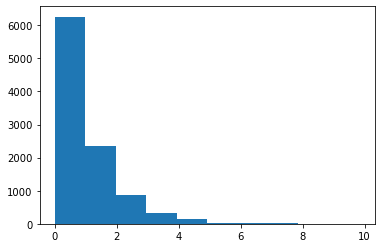

In [20]:
plt.hist(Y[0])

In [21]:
import pandas as pd


In [22]:
df = pd.DataFrame({'x':Y[0], 'y':Y[1]})

In [25]:
df['x_rank'] = df['x'].rank(pct=True)
df['y_rank'] = df['y'].rank(pct=True)

In [27]:
df

,x,y,x_rank,y_rank
0,0.157390,0.608363,0.1450,0.4481
1,2.799775,0.718059,0.9381,0.5037
2,0.721967,0.704063,0.5136,0.4968
3,0.471719,1.433956,0.3729,0.7553
4,3.550648,1.344205,0.9728,0.7380
...,...,...,...,...
9995,0.398443,0.380601,0.3265,0.3112
9996,0.787424,0.293384,0.5449,0.2507
9997,0.949402,0.807890,0.6102,0.5422
9998,3.237509,2.059285,0.9613,0.8709


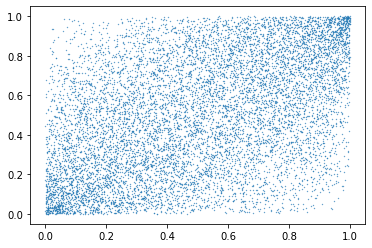

In [30]:
plt.scatter(df['x_rank'],df['y_rank'],s=0.1)

In [ ]:
'''
Gaussian Copula 在統計模擬中是一個非常實用且靈活的工具，
因為它允許保留個別變數的邊際分布情況下，
**模擬具有指定線性相關性的多維資料。
'''